In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(conf_matrix, labels, title="Matriz de Confusión", figsize=(10, 7), cmap="Blues"):
    """
    Plots a heatmap for a given confusion matrix.

    Parameters:
        conf_matrix (array-like): The confusion matrix to visualize.
        labels (list): The list of class labels for the x and y axes.
        title (str): Title of the plot. Default is "Matriz de Confusión".
        figsize (tuple): Figure size. Default is (10, 7).
        cmap (str): Colormap for the heatmap. Default is "Blues".
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax)
    plt.title(title)
    plt.xlabel("Predicciones")
    plt.ylabel("Valores Reales")
    plt.show()

In [4]:
import re

def split_url_function(url):
  split_url_list = url.split("/")
  while "" in split_url_list:
    split_url_list.remove("")
  domain=split_url_list[1].split(".")
  top_level_domain = domain[-1]
  while "" in domain:
    domain.remove("")
  domain = domain[0:-1]
  punc = []
  quantity_punctuatuion = 0
  quantity_numbers = 0
  for x in range (len(domain)):
    quantity_punctuatuion += len(re.findall(r'[^a-zA-Z0-9]',domain[x]))
    quantity_numbers += len(re.findall(r'[0-9]',domain[x]))
    punc = punc + re.findall(r'[^a-zA-Z]',domain[x])
    domain[x] = re.sub("[^a-zA-Z\\s]", ' ',domain[x])

  quantity_punctuatuion_total = len(punc)
  domain.append(' '.join(punc))
  protocol = re.sub("[^a-zA-Z\\s]", '',split_url_list[0])


  return protocol, domain, split_url_list,top_level_domain,len(split_url_list[1]),quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers
protocol,domain,split_url,top_level_domain,size_url,quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers = split_url_function("https://1web.wh!at232-sapp.com/")
print(protocol,domain,split_url,top_level_domain,size_url,quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers)

https [' web', 'wh at    sapp', '1 ! 2 3 2 -'] ['https:', '1web.wh!at232-sapp.com'] com 22 2 6 4


In [85]:
import pandas as pd
import numpy as np


data = pd.read_csv('./file/urls.txt', sep='\t')
data.head(-5)

,url,dangerous
0,https://www.yanbal.com/ec//corporate/,0.0
1,https://clmd.pe/P1dxfl,0.0
2,https://amazon.com/z/jhlwGskSg,0.0
3,https://www.studiof.com.co/sms/tencard-day,0.0
4,https://ahnp.vercel.app/intest.html,1.0
...,...,...
264,https://adwrlak.com/,1.0
265,https://bolly-dropbox.top/,1.0
266,https://correosprepago.bnext.es/card-number,1.0
267,https://appie.epaqueticorreospaq.com/,1.0


In [87]:
column_protocol = []
column_domain = []
column_size_domain = []
column_top_level_domain = []
column_size_url = []
column_quantity_punctuatuion = []
column_quantity_punctuatuion_total = []
column_quantity_numbers = []
for x in data['url']:
  protocol,domain,split_url,top_level_domain,size_url,quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers = split_url_function(x)
  column_protocol.append(protocol)
  column_domain.append(" ".join(domain))
  column_size_domain.append(len(domain))
  column_top_level_domain.append(top_level_domain)
  column_size_url.append(size_url)
  column_quantity_punctuatuion.append(quantity_punctuatuion)
  column_quantity_punctuatuion_total.append(quantity_punctuatuion_total)
  column_quantity_numbers.append(quantity_numbers)
data["protocol"] = column_protocol
data["domain"] = column_domain
data["size_domain"] = column_size_domain
data["top_level_domain"] = column_top_level_domain
data["size_url"] = column_size_url
data["quantity_punctuatuion"] = column_quantity_punctuatuion
data["quantity_punctuatuion_total"] = column_quantity_punctuatuion_total
data["quantity_numbers"] = column_quantity_numbers
data['dangerous'] = data['dangerous'].fillna(0)
data.head(-4)

,url,dangerous,protocol,domain,size_domain,top_level_domain,size_url,quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers
0,https://www.yanbal.com/ec//corporate/,0.0,https,www yanbal,3,com,14,0,0,0
1,https://clmd.pe/P1dxfl,0.0,https,clmd,2,pe,7,0,0,0
2,https://amazon.com/z/jhlwGskSg,0.0,https,amazon,2,com,10,0,0,0
3,https://www.studiof.com.co/sms/tencard-day,0.0,https,www studiof com,4,co,18,0,0,0
4,https://ahnp.vercel.app/intest.html,1.0,https,ahnp vercel,3,app,15,0,0,0
...,...,...,...,...,...,...,...,...,...,...
265,https://bolly-dropbox.top/,1.0,https,bolly dropbox -,2,top,17,1,1,0
266,https://correosprepago.bnext.es/card-number,1.0,https,correosprepago bnext,3,es,23,0,0,0
267,https://appie.epaqueticorreospaq.com/,1.0,https,appie epaqueticorreospaq,3,com,28,0,0,0
268,https://wellsfarg-docu.vercel.app/,1.0,https,wellsfarg docu vercel -,3,app,25,1,1,0


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack, csr_matrix


# Separar características y etiqueta
text_columns  = data[["protocol", "domain", "top_level_domain"]]
tfidf_vectorizers = {}
tfidf_features = []
for column in text_columns:
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform(data[column])
    tfidf_vectorizers[column] = vectorizer  # Guardar el vectorizador para análisis futuro
    tfidf_features.append(tfidf)
X_hstack=hstack(tfidf_features)  # Combina en una matriz dispersa
# Añadir la columna numérica
numeric_column = data[['size_domain','size_url','quantity_punctuatuion_total']].values  # Convertir la columna en formato numpy
#numeric_column_sparse = csr_matrix(numeric_column)
X_combined = hstack([X_hstack, numeric_column])


# Combinar las características TF-IDF de todas las columnas
X = X_combined
y = data["dangerous"]

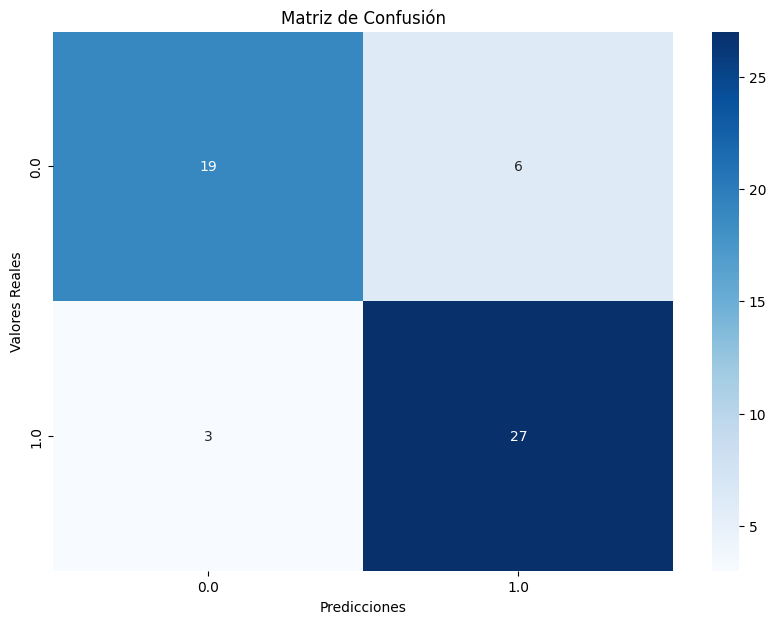

Accuracy: 0.8363636363636363
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.76      0.81        25
         1.0       0.82      0.90      0.86        30

    accuracy                           0.84        55
   macro avg       0.84      0.83      0.83        55
weighted avg       0.84      0.84      0.84        55



In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión logística
model = LogisticRegression()
model_fit = model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)



matrix = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(matrix, data['dangerous'].unique())
# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

In [83]:
#PREDICT
protocol,domain,split_url,top_level_domain,size_url,quantity_punctuatuion,quantity_punctuatuion_total,quantity_numbers =  split_url_function("https://amazon.tmizlmnagcojp.top/")
new_data = {
    "protocol": protocol,
    "domain": " ".join(domain),
    "top_level_domain": top_level_domain,
    "size_domain": len(domain),
    "size_url": size_url,
    "quantity_punctuatuion": quantity_punctuatuion,
    "quantity_punctuatuion_total": quantity_punctuatuion_total,
    "quantity_numbers": quantity_numbers
}

# Transformar cada columna de texto con su vectorizador correspondiente
new_tfidf_features = []
for column in ["protocol", "domain", "top_level_domain"]:
    vectorizer = tfidf_vectorizers[column]  # Recuperar el vectorizador entrenado
    tfidf = vectorizer.transform([new_data[column]])  # Transformar la columna
    new_tfidf_features.append(tfidf)

# Combinar las transformaciones TF-IDF
new_X_hstack = hstack(new_tfidf_features)

# Añadir la columna numérica
numeric_column = np.array([[new_data['size_domain'], new_data['size_url'],new_data['quantity_punctuatuion_total']]])
new_X_combined = hstack([new_X_hstack, numeric_column]) # Combinar TF-IDF y numérica

# Realizar la predicción
new_prediction = model.predict(new_X_combined)
print("Predicción para el nuevo valor:", new_prediction)

# Opcional: Probabilidades de pertenecer a cada clase
new_prediction_proba = model.predict_proba(new_X_combined)
print("Probabilidades para cada clase:", new_prediction_proba)


# Calcular probabilidades para el nuevo datoS
new_probabilities = model.predict_proba(new_X_combined)[:, 1]

# Aplicar el umbral personalizado
#new_threshold = 0.2
#new_custom_predictions = (new_probabilities >= new_threshold).astype(int)

#print("Probabilidad estimada:", new_probabilities)
#print("Predicción con umbral 60%:", new_custom_predictions)

Predicción para el nuevo valor: [1.]
Probabilidades para cada clase: [[0.16993005 0.83006995]]


In [90]:
import joblib

joblib.dump(model_fit, "./../api/trained_model.joblib")
joblib.dump(tfidf_vectorizers, "./../api/vectorizer.joblib")
print(f"Model saved to {model_fit}")

Model saved to LogisticRegression()
